In [298]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest, chisquare, norm, chi2
from utils.plotting import histogram

np.random.seed(42)


In [299]:
a = 5
c = 1
M = 16
x0 = 1
size = 10000

In [300]:

def linear_congruential_generator(a, c, M, x0, size):
    output = np.zeros(shape=size)
    output[0] = x0
    for i in range(1, size):
        y = (a * output[i-1] + c)
        val = y - (y // M) * M
        output[i] = val

    return output


In [301]:

def run_and_display_kolmogorov_smirnov_test(output):
    # Normalize the output to the range [0, 1]
    normalized_output = output / np.max(output)
    
    # Perform the Kolmogorov-Smirnov test against a uniform distribution
    ks_statistic, p_value = kstest(normalized_output, 'uniform')
    
    print(f"KS Statistic: {ks_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

def run_and_display_chi_squared_test(output, bins=10):
    # Perform the Chi-squared test
    observed_freq, _ = np.histogram(output, bins=bins)
    expected_freq = [len(output) / bins] * bins  # Expected frequency for a uniform distribution
    chi2_statistic, p_value = chisquare(observed_freq, f_exp=expected_freq)
    
    print(f"Chi-squared Statistic: {chi2_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")


<Axes: title={'center': 'Histogram of LCG(a=5, c=1, M=16, x0=1)'}, xlabel='Value', ylabel='Frequency'>

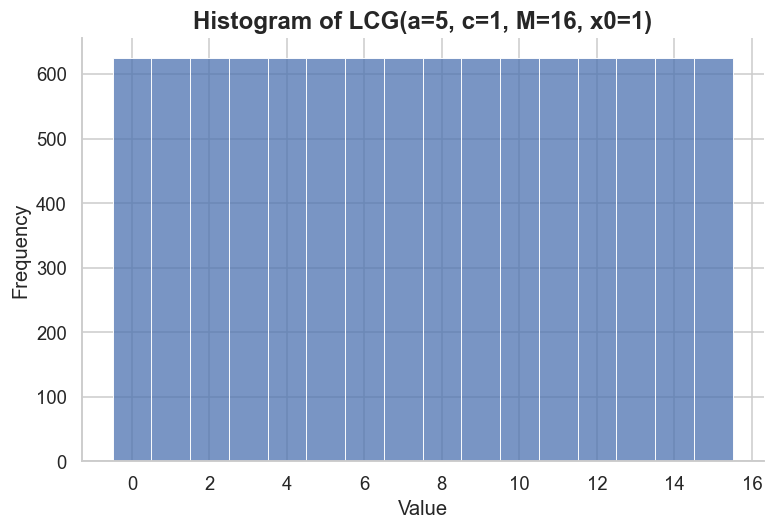

In [302]:

output = linear_congruential_generator(a, c, M, x0, size)
# plot_histogram(output, bins=16)
histogram(output, bins="auto", discrete=True, title=f"Histogram of LCG(a={a}, c={c}, M={M}, x0={x0})", xlabel="Value", ylabel="Frequency")

In [303]:
# On simple Linear congruential generator
print("Simple Linear Congruential Generator: (chi squared )")
run_and_display_chi_squared_test(output, bins=16)

# Kolmogorov-Smirnov test
##### Kolmogorov-Smirnov test #####
print("\nKolmogorov-Smirnov Test for Linear Congruential Generator:")
run_and_display_kolmogorov_smirnov_test(output)


Simple Linear Congruential Generator: (chi squared )
Chi-squared Statistic: 0.0000
P-value: 1.0000

Kolmogorov-Smirnov Test for Linear Congruential Generator:
KS Statistic: 0.0625
P-value: 0.0000



System Available Random Generator: (Kolmogorov-Smirnov test)
KS Statistic: 0.0655
P-value: 0.0000

System Available Random Generator: (chi squared )
Chi-squared Statistic: 9.2640
P-value: 0.8633


<Axes: title={'center': 'Histogram of System Generated Random Numbers'}, xlabel='Value', ylabel='Frequency'>

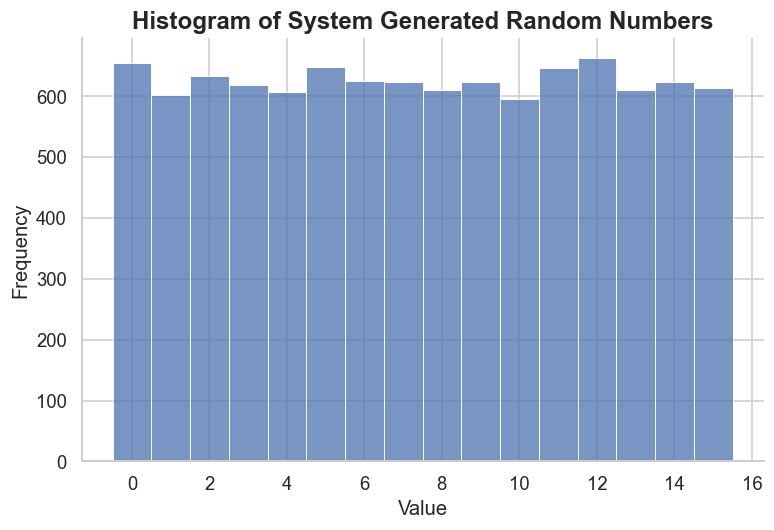

In [304]:

system_output = np.random.randint(low=0, high=16, size=size)
##### System available random generator #####
print("\nSystem Available Random Generator: (Kolmogorov-Smirnov test)")
run_and_display_kolmogorov_smirnov_test(system_output)

# On system available random generator
print("\nSystem Available Random Generator: (chi squared )")
run_and_display_chi_squared_test(system_output, bins=16)

histogram(system_output, discrete=True, title="Histogram of System Generated Random Numbers", xlabel="Value", ylabel="Frequency")

# Run above_below tests

wald-wolfowitz


In [305]:
def above_below_test(output):
    median = np.median(output)
    n1 = np.sum(output > median)
    n2 = np.sum(output < median)
    n = n1 + n2
    
    runs_above = 0
    runs_below = 0
    
    for i in range(1, len(output)):
        if output[i] > median and output[i-1] <= median:
            runs_above += 1
        elif output[i] <= median and output[i-1] > median:
            runs_below += 1
            
    print(f"Runs above median: {runs_above}, Runs below median: {runs_below}")
    T = runs_above + runs_below + 1 # Total runs (including the first run)

    # Theoretical mean and std of T under H0 (from slide)
    mu    = 2*n1*n2 / n + 1
    var   = 2*n1*n2*(2*n1*n2 - n1 - n2) / (n**2 * (n - 1))
    sigma = np.sqrt(var)
    
    # Z-score, then two-sided p-value from the Normal CDF
    Z       = (T - mu) / sigma
    p_value = 2 * (norm.sf(-abs(Z)))
    
    print(f"Above median: {n1}, Below median: {n2}")
    print(f"Observed runs  T = {T}")
    print(f"Expected under H0: μ = {mu:.2f}, σ = {sigma:.4f}")
    print(f"Z = {Z:.4f},  p-value = {p_value:.4f}")
    
    return T, n1, n2, p_value
    
    
print("\nAbove-Below Test for Linear Congruential Generator:")
T, n1, n2, p_value = above_below_test(output)


Above-Below Test for Linear Congruential Generator:
Runs above median: 1875, Runs below median: 1875
Above median: 5000, Below median: 5000
Observed runs  T = 3751
Expected under H0: μ = 5001.00, σ = 49.9975
Z = -25.0013,  p-value = 2.0000


In [306]:
T, n1, n2, p_value = above_below_test(system_output)

Runs above median: 2540, Runs below median: 2540
Above median: 4986, Below median: 4391
Observed runs  T = 5081
Expected under H0: μ = 4670.62, σ = 48.2199
Z = 8.5105,  p-value = 2.0000


# Run Tests 2 : Up/Down from Knuth


In [307]:
def up_down_test(output):
    n = len(output)
    runs = []
    counter = 1
    for i in range(1, n):
        if output[i] > output[i-1]:
            counter += 1
        else:
            runs.append(counter)
            counter = 1
    runs.append(counter)  # Append the last run
    
       # Step 2: bin into R — counts for lengths 1, 2, 3, 4, 5, ≥6
    R = np.zeros(6)
    for length in runs:
        R[min(length - 1, 5)] += 1

    # A matrix and B vector from slide
    A = np.array([
        [4529.4,  9044.9, 13568,  18091,  22615,  27892 ],
        [9044.9, 18097,  27139,  36187,  45234,  55789 ],
        [13568,  27139,  40721,  54281,  67852,  83685 ],
        [18091,  36187,  54281,  72414,  90470, 111580 ],
        [22615,  45234,  67852,  90470, 113262, 139476 ],
        [27892,  55789,  83685, 111580, 139476, 172860 ],
    ])
    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    # Step 3: test statistic ~ chi2(6)
    diff    = R - n * B
    Z       = (1 / (n - 6)) * diff @ A @ diff
    p_value = chi2.sf(Z, df=6)

    print(f"Observed R  = {R.astype(int)}")
    print(f"Expected nB = {(n * B).round(1)}")
    print(f"Z = {Z:.4f},  p-value = {p_value:.4f}")

    return Z, p_value

print("\nUp-Down Test for Linear Congruential Generator:")
Z, p_value = up_down_test(output)
print("\nUp-Down Test for System Available Random Generator:")
Z, p_value = up_down_test(system_output)
            


Up-Down Test for Linear Congruential Generator:
Observed R  = [1251 1250 1251  624    0    0]
Expected nB = [1666.7 2083.3  916.7  263.9   57.5   11.9]
Z = 1116.3560,  p-value = 0.0000

Up-Down Test for System Available Random Generator:
Observed R  = [2010 2272  841  180   37    3]
Expected nB = [1666.7 2083.3  916.7  263.9   57.5   11.9]
Z = 143.6554,  p-value = 0.0000


In [308]:
def up_down_test_3(output):
    n = len(output)

    # Step 1: sign sequence (+1 = up, -1 = down, 0 = tie)
    signs = np.sign(np.diff(output))

    # Remove ties; adjust n so formula still uses original observation count
    signs = signs[signs != 0]
    n_eff = len(signs) + 1  # equals n when no ties

    # Step 2: count total runs of consecutive identical signs
    X = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1]:
            X += 1

    # Step 3: Z-statistic and two-sided p-value (from slide formula)
    mu    = (2 * n_eff - 1) / 3
    sigma = np.sqrt((16 * n_eff - 29) / 90)
    Z       = (X - mu) / sigma
    p_value = 2 * norm.sf(abs(Z))

    print(f"Total runs       X = {X}")
    print(f"Expected under H0: μ = {mu:.4f},  σ = {sigma:.4f}")
    print(f"Z = {Z:.4f},  p-value = {p_value:.4f}")

    return X, Z, p_value

print("\nUp-Down Test 3 for Linear Congruential Generator:")
X, Z, p_value = up_down_test_3(output)

print("\nUp-Down Test 3 for System Available Random Generator:")
X, Z, p_value = up_down_test_3(system_output)


Up-Down Test 3 for Linear Congruential Generator:
Total runs       X = 6250
Expected under H0: μ = 6666.3333,  σ = 42.1599
Z = -9.8751,  p-value = 0.0000

Up-Down Test 3 for System Available Random Generator:
Total runs       X = 6493
Expected under H0: μ = 6252.3333,  σ = 40.8296
Z = 5.8944,  p-value = 0.0000
